In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.special import logit, expit

from datetime import datetime
import torch
from tqdm.auto import tqdm
import pickle
from pathlib import Path

import sys
sys.path.insert(0, str(Path.cwd().parents[0] / '2_Propensities'))
import SASRec_class as sasrec

np.random.seed(42)
if np.random.choice(np.arange(1000)) != 102:
    raise ValueError("Random seed is not set correctly.")

# 1 Load Data

In [ ]:
base_artifacts = Path.cwd().resolve().parents[1] / 'CausalI2I_artifacts'
data_path = base_artifacts / 'Datasets' / 'Simulation'

model_path = base_artifacts / 'SASRec_Models' / 'simulation'
with open(model_path / f'init_dict.pkl', 'rb') as f:
    init_dict_loaded = pickle.load(f)
sasrec_model = sasrec.SASRecTorch(**init_dict_loaded)
sasrec_model.load(model_path / f'sasrec.pt')
L = init_dict_loaded['max_seq_len']

with open(data_path / f'test_users.pkl', 'rb') as f:
    test_users = pickle.load(f)

data = pd.read_csv(
    data_path / 'simulation_data.csv'
)
unique_items = data['item_id'].unique()
users_dict = data.groupby('user_id')['item_id'].apply(list).to_dict()

/home/gouni/.local/lib/python3.10/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Model loaded from /home/gouni/CausalI2I_new_artifacts/SASRec_Models/simulation/sasrec.pt.
num_items:     3001
max_seq_len:   50
device:        cuda
batch_size:    2048
lr:            0.001
weight_decay:  0.0
num_epochs:    10
saved_at:      2026-08-15 09:34:05
note:          None


In [3]:
padding_idx = data['item_id'].max() + 1

windows_valid = []
for user_id in tqdm(users_dict):
    padded_sequence = [padding_idx] * (L - 1) + users_dict[user_id]
    for i in range(len(padded_sequence) - L):
        if user_id in test_users:
            window = padded_sequence[i:i+L+1]
            windows_valid.append(window)
            
windows_valid = np.array(windows_valid)

print(f"Shape of windows_valid: {windows_valid.shape}")

  0%|          | 0/5000 [00:00<?, ?it/s]

Shape of windows_valid: (149000, 51)


# 2 Train Calibrator

In [4]:
def get_sigmoid_calibration_df(model, windows, batch_size=1024, sample_size=20_000, n_bins=40):
    model.eval()

    rng = np.random.default_rng(seed=42)
    print(f"Sampling {sample_size:,} windows from {len(windows):,} total windows...")
    sample_indices = rng.choice(len(windows), size=sample_size, replace=False)
    windows_sample = windows[sample_indices]

    H = windows_sample[:, :L]
    next_items = windows_sample[:, L]

    H_tensor = torch.as_tensor(H, dtype=torch.long)
    A_tensor = torch.as_tensor(unique_items, dtype=torch.long, device=model.device)

    all_probs = []
    all_labels = []

    with torch.no_grad():
        for start in tqdm(range(0, len(H_tensor), batch_size)):
            end = start + batch_size

            H_batch = H_tensor[start:end].to(model.device)
            B = H_batch.shape[0]

            candidates = A_tensor.unsqueeze(0).expand(B, -1)  # (B, n_A)

            logits = model.predict_scores(
                seq=H_batch,
                candidates=candidates
            )

            probs = torch.sigmoid(logits).cpu().numpy()

            labels = (
                next_items[start:end, None] == unique_items[None, :]
            ).astype(int)

            all_probs.append(probs.reshape(-1))
            all_labels.append(labels.reshape(-1))

    probs = np.concatenate(all_probs)
    labels = np.concatenate(all_labels)

    print(f"Total number of predictions: {len(probs):,}")

    calib_df = pd.DataFrame({
        "p_hat": probs,
        "y": labels
    })

    print("Q-cutting into bins...")
    calib_df["bin"] = pd.qcut(calib_df["p_hat"], q=n_bins, duplicates="drop")

    print("Aggregating by bins...")
    return (
        calib_df.groupby("bin", observed=True)
        .agg(
            mean_p_hat=("p_hat", "mean"),
            empirical_p=("y", "mean"),
            n=("y", "size")
        )
        .reset_index(drop=True)
    )

In [5]:
calib_table = get_sigmoid_calibration_df(
    model=sasrec_model,
    windows=windows_valid,
    batch_size=1024,
    sample_size=30_000,
    n_bins=30
)

print(f"\nShape of calibration DataFrame: {calib_table.shape}")

Sampling 30,000 windows from 149,000 total windows...


  0%|          | 0/30 [00:00<?, ?it/s]

Total number of predictions: 90,000,000
Q-cutting into bins...
Aggregating by bins...

Shape of calibration DataFrame: (30, 3)


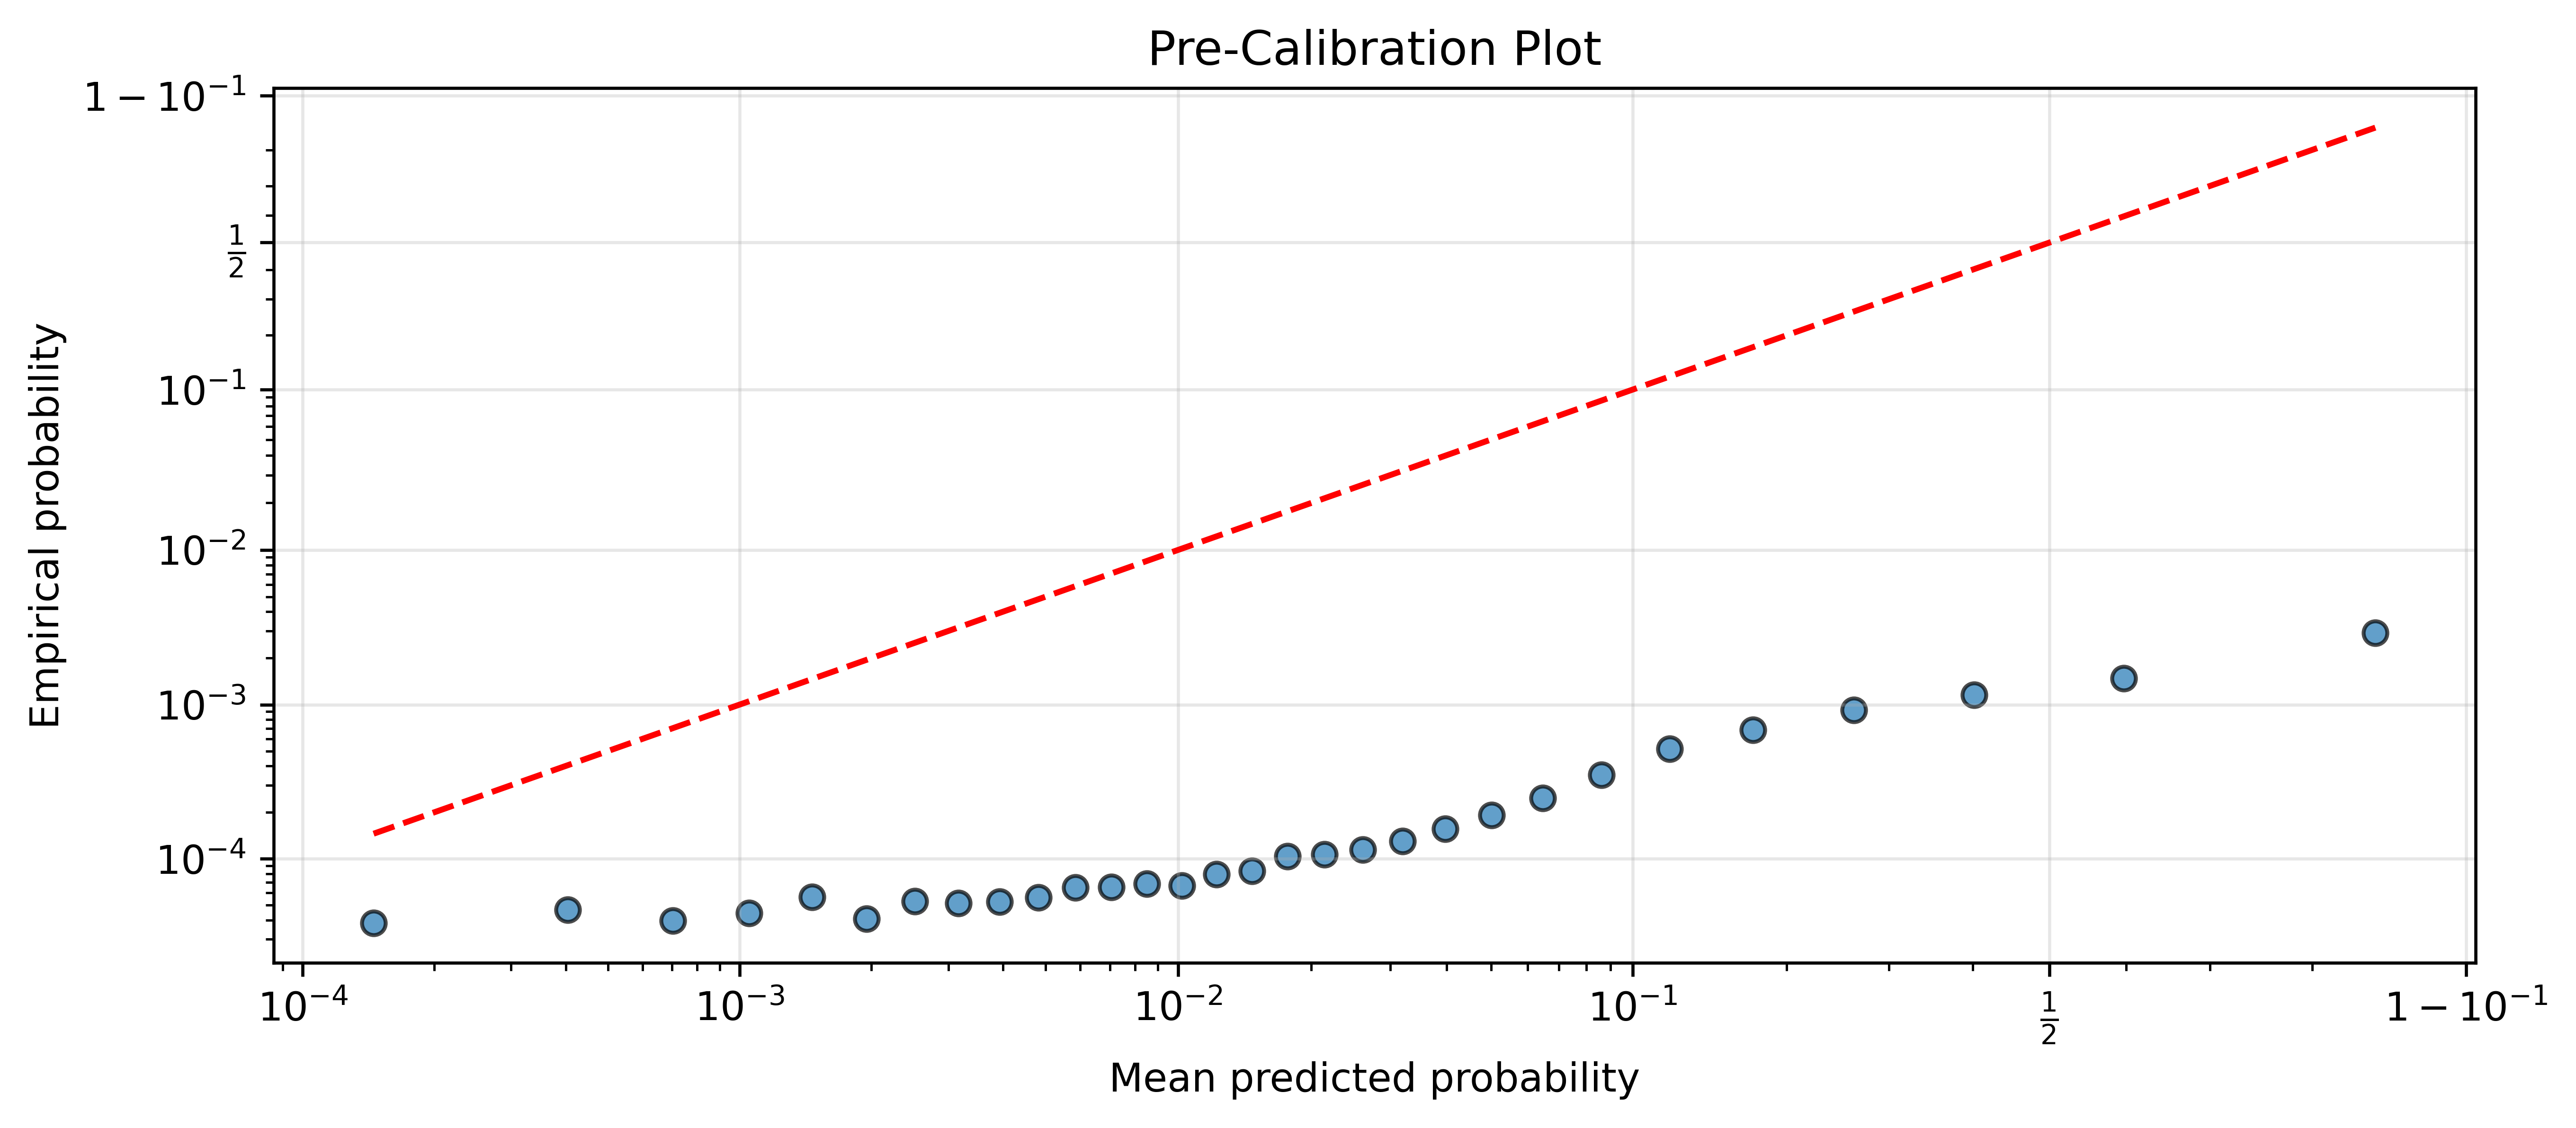

In [6]:
p_hat = calib_table["mean_p_hat"].values
emp_p = calib_table["empirical_p"].values

plt.figure(figsize=(10, 4), dpi=600)
plt.scatter(p_hat, emp_p, alpha=0.7, edgecolors='k')
plt.plot(p_hat, p_hat, color='red', linestyle='--', label='Perfect Calibration')

plt.xscale('logit')
plt.yscale('logit')

plt.xlabel("Mean predicted probability")
plt.ylabel("Empirical probability")
plt.title("Pre-Calibration Plot")
plt.grid(alpha=0.3)
plt.show()

In [7]:
eps = 1e-12

p = np.clip(p_hat, eps, 1 - eps)

X = np.column_stack([
    np.log(p),
    np.log(1-p)
])
X = sm.add_constant(X)

res = sm.GLM(
    emp_p,
    X,
    family=sm.families.Binomial()
).fit()
print(res.summary())

beta = res.params
print(f"\nCalibration Function:\n\tp_calibrated = expit({beta[0]:.4f} + {beta[1]:.4f} * log(p_hat) + {beta[2]:.4f} * log1p(-p_hat))")

def calibrator(p):
    p = np.clip(p, eps, 1 - eps)
    z = beta[0] + beta[1] * np.log(p) + beta[2] * np.log1p(-p)
    return expit(z)

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                   30
Model:                            GLM   Df Residuals:                       27
Model Family:                Binomial   Df Model:                            2
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:              -0.070944
Date:                Sat, 15 Aug 2026   Deviance:                   0.00039474
Time:                        09:34:38   Pearson chi2:                 0.000505
No. Iterations:                    12   Pseudo R-squ. (CS):          0.0006088
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -6.4915     31.457     -0.206      0.8

# 3 Calibrate

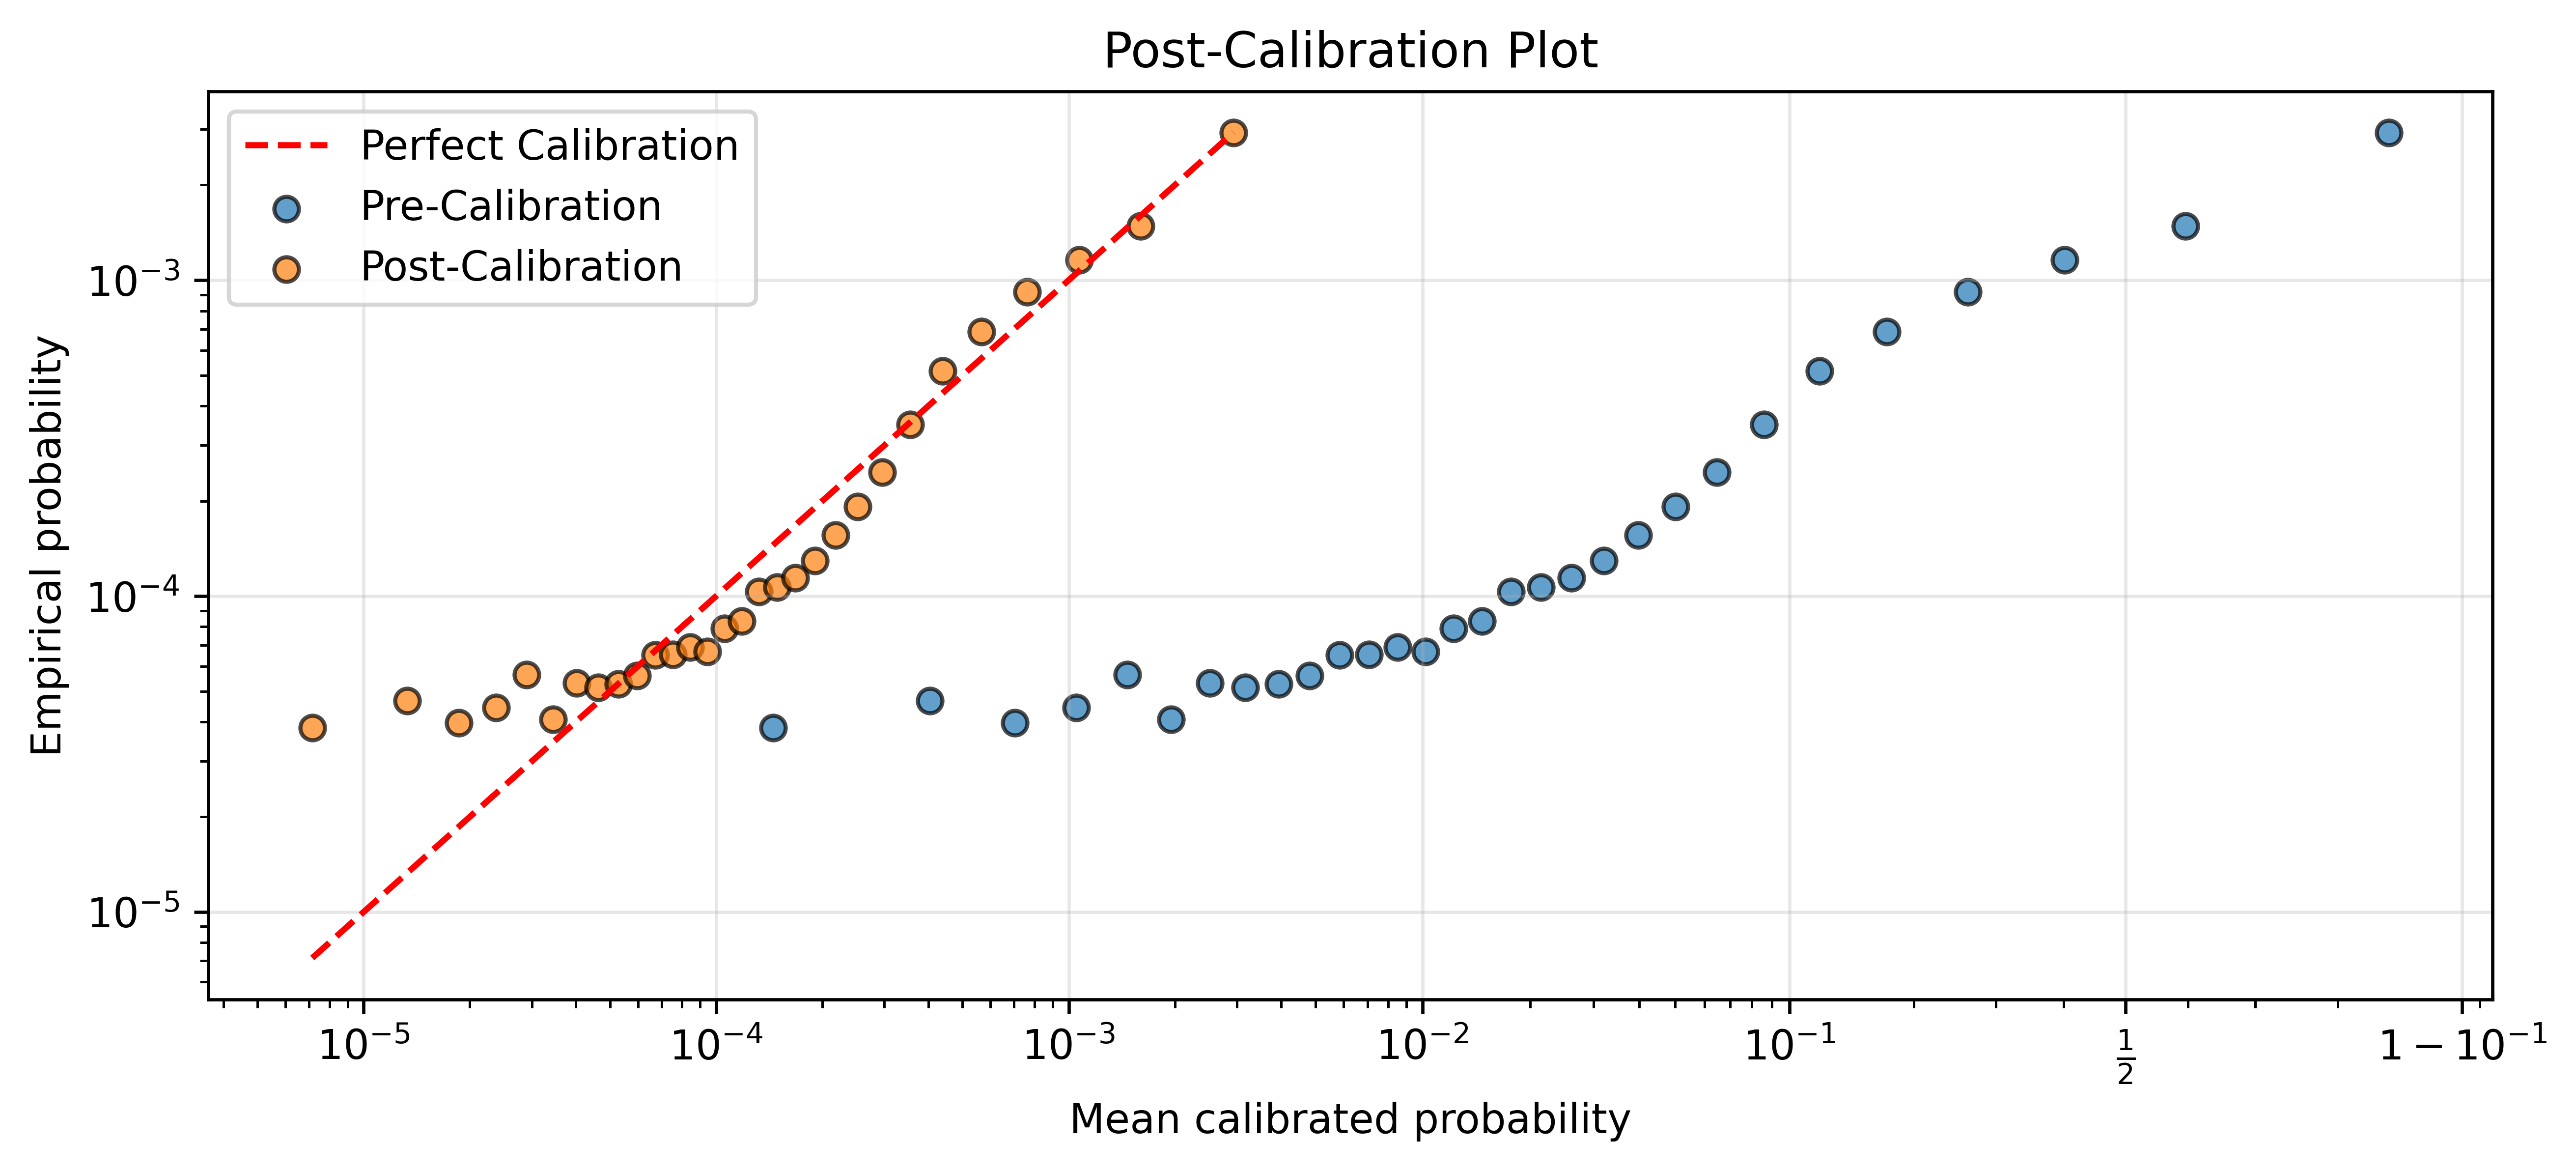

In [8]:
cal_p = calibrator(p_hat)

plt.figure(figsize=(10, 4), dpi=600)

m = min(cal_p.min(), emp_p.min())
M = max(cal_p.max(), emp_p.max())
plt.plot(cal_p, cal_p, color='red', linestyle='--', label='Perfect Calibration')
plt.scatter(p_hat, emp_p, alpha=0.7, edgecolors='k', label='Pre-Calibration')
plt.scatter(cal_p, emp_p, alpha=0.7, edgecolors='k', label='Post-Calibration')

plt.xscale("logit")
plt.yscale("logit")

plt.xlabel("Mean calibrated probability")
plt.ylabel("Empirical probability")
plt.title("Post-Calibration Plot")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

# 4 Save Calibrator Parameters

In [9]:
calibrator_params = {
    "beta": beta,
    "description": f"p_calibrated = expit({beta[0]:.3f} + {beta[1]:.3f} * log(p_hat) + {beta[2]:.3f} * log(1-p_hat))"
}

with open(model_path / f'calibrator_params.pkl', 'wb') as f:
    pickle.dump(calibrator_params, f)

In [10]:
print(f"End: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

End: 2026-08-15 09:34:40
